# What do the SARS-Cov-2 genes do?


One process in the analysis of a new organism is annotating the genome. The first step of this analysis is to find potential genes through identifying open reading frames (ORFs). 
After this, the next question is which of these correspond to actual genes?

To answer this, we will lean on what we know about evolution. If two species are morphologically different, their genetic material must also differ substantially. Right? Not exactly. Evolution conserved many genes crucial for survival. The degree of conservation is surprising. For example, while we would expect to share many genes with the chimpanzee, our closest relative, we would expect almost no similarity in our genetic material with bananas. The numbers tell us otherwise. While sharing 96% of our genes with the chimpanzee, we also share 60% of our genes with bananas! These similar genes in humans and bananas encode proteins that carry similar functions.

Two genes with similar sequences may perform similar functions. Genes like these are called homologous genes. Or, more precisely, in our case, these would be orthologous genes (see the figure below). A pair of orthologous genes are genes from two related species originating from a common ancestor (e.g., humans and chimpanzees). Due to the evolution, the two nucleotide or protein sequences might differ slightly but not overwhelmingly.

<div>
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/d/d8/Ortholog_paralog_analog_%28homologs%29.svg/1200px-Ortholog_paralog_analog_%28homologs%29.svg.png" width="500">
</div>

*Author: Thomas Shafee, Licence: CC BY 4.0*

The human-banana example demonstrates that these two organisms don't have to be that closely related! If we tried to determine the gene function in humans using bananas as a reference, we could infer the role of over 60% of the genes. However, using two closely related organisms would undoubtedly give us more robust results. We would be better off choosing the genome of a mouse or a chimpanzee as our reference.

Scientists have studied hundreds of viruses and determined the functions of most of their genes. Using viruses similar in sequence to SARS-Cov-2, we can characterize the SARS-CoV-2 ORFs to determine if they are the actual genes, and think about their function. Knowing what each gene does might help us find a way to fight the infection and potentially even find treatments for COVID-19. 

#### Please ensure each answer is completed in the single cell of the notebook immediately following the question, and that all answers are in ```markdown``` format.

Once you have completed the notebook, make sure you save it and submit it via Moodle.

All questions are worth between 4 and 10 marks. There are a total of *40 marks* available in this workbook. There is an extra bonus problem for *10 marks*. 
  
Total notebook marks will be scaled to a **course mark out of 10** to contribute to your course total.

In [2]:
import numpy as np
from Bio import Entrez

In [3]:
# In order to import from the python file without hassle, we add the current
# directory to the python path
import sys; sys.path.append(".")

Let's let the nice folks at NCBI know who we are.

In [4]:
Entrez.email = "z5582768@student.unsw.edu.au"

## Finding SARS-CoV-2's closest relatives

In the first part of this assignment, we will analyze several coronavirus genomes to determine which are most similar to SARS-CoV-2. We will then use the viruses with the most similar sequence as reference genomes to assign functions to SARS-CoV-2 ORFs.

To find the closest reference genomes, we will align the SARS-CoV-2 sequence to each candidate coronavirus genome. The virus genomes with the highest alignment scores will be our most closely-related viruses.

Notice that computing an alignment between two sequences of length $N$ and $M$ requires the computation of a dynamic programming table with $N \cdot M$ entries. The size of this matrix is sufficiently small for short sequences. But even the short genomes, like viral genomes, are generally too long for this approach. Instead of computing similarities from the entire genomes, we will only focus on the spike protein sequence. In general, we would prefer to align the whole nucleotide sequences, but for this assignment, considering only a spike protein will be sufficient. The spike protein is also one of the essential parts of any coronavirus, as it is the one that grants the virus entry to host cells. 

Considering spike proteins alone reduces the sequence lengths from ~30k (entire virus) to around 1.3k (spike protein). Nevertheless, do your best to write fast, efficient Python code. Each `global_alignment` call on 1.3k long protein sequences should take around 30 to 60 seconds. 
We have to calculate 20 comparisons, which takes roughly 10 to 20 minutes.

In [5]:
accession_codes = {
    # 6 known human coronaviruses
    "Human-SARS": "NC_004718",
    "Human-MERS": "NC_019843",
    "Human-HCoV-OC43": "NC_006213",
    "Human-HCoV-229E": "NC_002645",
    "Human-HCoV-NL63": "NC_005831",
    "Human-HCoV-HKU1": "NC_006577",
    
    # Bat
    "Bat-CoV MOP1": "EU420138",
    "Bat-CoV HKU8": "NC_010438",
    "Bat-CoV HKU2": "NC_009988",
    "Bat-CoV HKU5": "NC_009020",
    "Bat-CoV RaTG13": "MN996532",
    "Bat-CoV-ENT": "NC_003045",
    
    # Other animals
    "Hedgehog-CoV 2012-174/GER/2012": "NC_039207",
    "Pangolin-CoV MP789": "MT121216",
    "Rabbit-CoV HKU14": "NC_017083",
    "Duck-CoV isolate DK/GD/27/2014": "NC_048214",
    "Feline infectious peritonitis virus": "NC_002306",  # cat
    "Giraffe-CoV US/OH3/2003": "EF424623",
    "Murine-CoV MHV/BHKR_lab/USA/icA59_L94P/2012": "KF268338",  # mouse
    "Equine-CoV Obihiro12-2": "LC061274",  # horse
}

Above is the list of coronaviruses and their corresponding NCBI accession codes that we will consider in this assignment. You can find the SARS-CoV-2 sequence in `data/sars_cov_2.fa`. This time, we will use the FASTA format to familiarize ourselves with the sequence file formats used in bioinformatics. You can easily read FASTA files using the `SeqIO.read` function from `biopython`.

We will only use part of the sequence, and to assess similarity, consider the spike protein alone. We will assume that we know the location of the spike protein in SARS-CoV-2 (strand=1, start=21562, stop=25384). We need to find a part of the sequence that encodes for the spike protein in all coronaviruses listed above. We can inspect each sequence's features to locate the spike protein. For this assignment, we will iterate through gene coding regions (CDS) for each coronavirus and find the one that codes for the "S" gene. Some coronaviruses do not include such annotation but instead report on a "spike protein" in the `product` field.

## Problem 1: Global alignment

**Task:** Use the template `global_alignment` function in the helper file to implement the Needleman-Wunsch algorithm for global sequence alignment. Use a "-" character for indels. Score the alignments using the BLOSUM62 substitution matrix. You can find it in `biopython`.

**[10 points]**

In [6]:
from helper_functions import global_alignment, scoring_function_blosum

result = global_alignment(
    "GTTAAC",
    "GTCAA",
    scoring_function_blosum
)

print(result)

('GTTAAC', 'GTCAA-', 10.0)


## Problem 2: Choosing our reference genomes

**Task:** Identify the three closest relatives to SARS-CoV-2. Use the `global_alignment` function you have just implemented, inspect their alignment scores, and select the three most similar sequences to our spike protein sequence. These will serve as reference genomes in Problem 4 of this assignment and help us determine the function of ORFs.

Save the full names of three coronaviruses with the closest matches to SARS-CoV-2's spike protein sequence as a Python list in the `three_closest_references` variable.

**[6 points]**

Then answer the following questions about global alignment and the three closest references.
- When aligning spike protein sequences with the global alignment, we used the BLOSUM62 substitution matrix by default. Examine the similarity of the protein alignments (the frequency of matching amino acids) and discuss whether it would be better to use the BLOSUM90 or BLOSUM45 substitution matrix in our case.
- The theory of evolution states that the SARS-CoV-2 virus must have evolved from some other virus in the past. Based on the three closest alignment references, is it more likely that SARS-CoV-2 jumped from another host organism or evolved from a human coronavirus? (We will explore this further in the following exercise.)

Store your answers in the `blosum_selection` and `viral_origin` variables, respectively.

**[4 points]**.

In [30]:
from Bio import SeqIO
import re

spikes = {}

for name, accession in accession_codes.items():
    handle = Entrez.efetch(db="nucleotide", id=accession, rettype="gb", retmode="text")
    record = SeqIO.read(handle, "genbank")
    handle.close()

    spike_seq = None
    # Loop through all features in this virus genome
    for feat in record.features:
        # Protein coding only
        if feat.type == "CDS":
            # Get gene names
            if "gene" in feat.qualifiers:
                genes = feat.qualifiers["gene"]
            else:
                genes = []

            found_spike_gene = False
            for g in genes:
                if re.fullmatch(r"S", g):
                    found_spike_gene = True

            # Get product annotations
            if "product" in feat.qualifiers:
                proteins = feat.qualifiers["product"]
            else:
                proteins = []

            found_protein_spike = False
            for p in proteins:
                if re.search(r"spike", p, re.IGNORECASE):
                    found_protein_spike = True

            if found_spike_gene or found_protein_spike:
                spike_seq = feat.qualifiers["translation"][0]
                # Stop searching once the spike protein has been found
                break

    spikes[name] = spike_seq

In [8]:
# Read from SARS-CoV-2
record = SeqIO.read("data/sars_cov_2.fa", "fasta")
genome = record.seq

# Slice out protein coding region
start = 21562
stop = 25384
spike_nuc = genome[start : stop]

# Convert nucleotides to amino acid of protein
spike_protein = spike_nuc.translate()
sars2_spike = str(spike_protein[0:-1])

In [9]:
# Store alignment score for each reference virus
align_scores = {}
# Store the actual aligned spike protein sequences for each reference virus
alignments = {}

for name, ref_spike in spikes.items():
    # Globally align the SARS-CoV-2 spike protein with the reference spike protein
    aligned_sars2, aligned_ref, score = global_alignment(sars2_spike, ref_spike, scoring_function_blosum)
    align_scores[name] = score
    alignments[name] = (aligned_sars2, aligned_ref)
    print(len(aligned_sars2), len(aligned_ref), name, score)

1277 1277 Human-SARS 5142.0
1368 1368 Human-MERS 1190.0
1378 1378 Human-HCoV-OC43 953.0
1312 1312 Human-HCoV-229E 294.0
1379 1379 Human-HCoV-NL63 479.0
1380 1380 Human-HCoV-HKU1 856.0
1388 1388 Bat-CoV MOP1 330.0
1392 1392 Bat-CoV HKU8 479.0
1289 1289 Bat-CoV HKU2 282.0
1369 1369 Bat-CoV HKU5 1229.0
1273 1273 Bat-CoV RaTG13 6523.0
1398 1398 Bat-CoV-ENT 902.0
1349 1349 Hedgehog-CoV 2012-174/GER/2012 1171.0
1274 1274 Pangolin-CoV MP789 6039.0
1399 1399 Rabbit-CoV HKU14 942.0
1332 1332 Duck-CoV isolate DK/GD/27/2014 239.0
1468 1468 Feline infectious peritonitis virus 168.0
1392 1392 Giraffe-CoV US/OH3/2003 927.0
1358 1358 Murine-CoV MHV/BHKR_lab/USA/icA59_L94P/2012 1037.0
1397 1397 Equine-CoV Obihiro12-2 872.0


In [11]:
scores = sorted(align_scores.items(), key=lambda x: x[1], reverse=True)
for i in range(0,3):
    print(scores[i])

('Bat-CoV RaTG13', 6523.0)
('Pangolin-CoV MP789', 6039.0)
('Human-SARS', 5142.0)


In [12]:
three_closest_references = [  # Enter the three most closely-related viruses
    "Bat-CoV RaTG13", "Pangolin-CoV MP789", "Human-SARS"
]

In [13]:
for virus in three_closest_references:
    aligned_sars2, aligned_ref = alignments[virus]

    matches = 0
    for i in range(0, len(aligned_sars2)):
        if aligned_sars2[i] == aligned_ref[i]:
            matches += 1

    percent = matches / len(aligned_sars2) * 100
    print(f"{virus}: = {percent:.1f}% identical")

Bat-CoV RaTG13: = 97.4% identical
Pangolin-CoV MP789: = 90.0% identical
Human-SARS: = 76.4% identical


In [ ]:
blosum_selection = """
Would it be better to use BLOSUM90 or BLOSUM45 substitution matrix in our case?

BLOSUM90 would be better than BLOSUM45. BLOSUM45 is derived from more distantly related protein sequences and 
is therefore more tolerant of substitutions over greater evolutionary distances. In contrast, BLOSUM90 is 
better suited to highly conserved sequences and penalises mismatches more strictly.

The three closest references are highly similar to SARS-CoV-2. RaTG13 and the pangolin virus have approximately
97.4% and 90% sequence identity with SARS-CoV-2. Human-SARS is less similar at 76.4%, but it is still much 
more closely related than sequences typically suited to BLOSUM45. Therefore, BLOSUM90 is the better choice for 
these alignments, because the sequences are closely related and mismatches should be penalised more strictly.
"""

In [ ]:
viral_origin = """
Is it more likely that SARS-CoV-2 jumped from another host organism or evolved from a human coronavirus?

It is much likely that SARS-CoV-2 jumped from another host organism than evolved from a human coronavirus. 
The two closest viruss to SARS-CoV-2 are the two animal viruses bat coronavirus (RaTG13, 97.4% identical) 
as well as pangolin coronavirus (MP789, 90.0% identical). The third closest is Human-SARS with 76.4% identical 
which is overall less similar than the two animal viruses. Closely related virsuses tend to share a recent common ancestor.
Thus since SARS-CoV-2 is most similar to bat and pangolin viruses, it suggests it came from an animal host and then was passed
into humans rather than evolving from a virus that was already circulating in humans. However, since this is purely based 
off of spike protein alone, it is suggestive rather than conclusive evidence. 
"""

## MiniBLAST

A sophisticated approach for characterizing any genetic sequence is BLAST. BLAST stores a database of annotated genes (usually from various organisms) and then uses local alignment and heuristic search to find database genes with a similar sequence to a query one. Assuming that genes with similar protein sequences perform similar functions, we can infer the function of a query sequence by looking at the function of any matching genes returned by BLAST. It is also possible that BLAST will not find suitable matches, which may signal that a sequence might not be an actual gene or protein. In this problem, we will implement our simplified BLAST version and call it MiniBLAST. We will use MiniBLAST to determine whether each of our candidate ORFs is a gene. And if it is a gene, we will use the annotations to determine what the gene does.

Please note that BLAST is a complicated, optimized, heuristic, state-of-the-art technique to obtain very good approximate solutions. BLAST can query thousands of sequences in seconds. Our implementation will be slightly less sophisticated and somewhat more constrained but conceptually similar to that of BLAST.

## Problem 3: Local alignment

**Task:** Use the template `local_alignment` in the helper file and implement the Smith-Waterman algorithm for local sequence alignment.

**[10 points]**

## Problem 4: Finding homologous genes

For this assignment, we have selected five promising SARS-CoV-2 ORFs. 

In [14]:
orf_candidates = {
    "ORF-1": (1, 11995, 13483),
    "ORF-2": (1, 26792, 27191),
    "ORF-3": (1, 23650, 25384),
    "ORF-4": (-1, 421, 667),
    "ORF-5": (1, 9133, 13483),
}

We will now use MiniBLAST to compare these ORFs to known, annotated genes from the three closely-related coronaviruses you have stored in `three_closest_references`. The goal is to find the best matching gene from the reference genomes and decide if the quality of the match is sufficient to claim that ORF is an actual gene. 

Hint: among the five ORFs included in the candidates, we have planted one that is not a true gene.

**Task:** We start by building a reference database. For each of the three closely-related coronaviruses from Problem 2, extract the coding regions (CDS) from each genome, and convert them to protein sequences. Store the name of the virus each protein sequence came from and its function. In our case, the gene's function is evident from its name, e.g., "spike protein", "ORF1ab", and similar. Given `orf_candidates`, compute the local alignment to each protein sequence in our database. Inspect each alignment and its corresponding score, and decide whether the alignment is sufficiently good to assume they perform the same function.

Save your answers into the `orf_matches` variable as indicated in the cell below. Each ORF should be assigned a *closest-organism*, reporting the reference virus with the closest match, and a *homologous-gene*, indicating which gene the ORF matched to. If two ORFs match the reference with the same score, report one of them. For ORFs with no match in the reference, use None for both fields.

**[10 points]**

In [15]:
# Convert to protein
orf_proteins = {}

for orf_name, (strand, start, stop) in orf_candidates.items():
    nuc = genome[start:stop]

    # If on reverse strand flip to translate
    if strand == -1:
        nuc = nuc.reverse_complement()

    protein = str(nuc.translate()).rstrip("*")
    # Store the ORF name and its translated protein sequence
    orf_proteins[orf_name] = protein

In [ ]:
# extracts all of its protein-coding genes/proteins for the three reference viruses
known_virus_proteins = {}

# Loop through the three closest coronavirus references
for virus in three_closest_references:
    accession = accession_codes[virus]
    handle = Entrez.efetch(db="nucleotide", id=accession, rettype="gb", retmode="text")
    record = SeqIO.read(handle, "genbank")
    handle.close()

    known_virus_proteins[virus] = {}

    # Go through each feature
    for feat in record.features:
        if feat.type == "CDS":
            protein = feat.qualifiers.get("product", [])
            genes = feat.qualifiers.get("gene", [])

            # Use the protein name if present
            if len(protein) > 0:
                gene_name = protein[0]
            # Otherwise use the gene name
            elif len(genes) > 0:
                gene_name = genes[0]

            nuc_seq = feat.extract(record.seq)
            protein = str(nuc_seq.translate()).rstrip("*")
            known_virus_proteins[virus][gene_name] = protein

In [27]:
from helper_functions import local_alignment

best_hits = {}
best_alignments = {}

for orf_name, orf_protein in orf_proteins.items():
    best_score = 0
    best_virus = None
    best_gene = None
    best_aligned1 = ""
    best_aligned2 = ""

    # Align ORF against every protein in the reference database
    for virus, genes in known_virus_proteins.items():
        for gene, ref_protein in genes.items():
            aligned_orf, aligned_ref, score = local_alignment(orf_protein, ref_protein, scoring_function_blosum)

            # Keep the highest-scoring match
            if score > best_score:
                best_score = score
                best_virus = virus
                best_gene = gene
                best_aligned1 = aligned_orf
                best_aligned2 = aligned_ref

    # Count identical positions in the best alignment
    matches = 0
    for i in range(len(best_aligned1)):
        if best_aligned1[i] == best_aligned2[i]:
            matches += 1

    if len(best_aligned1) > 0:
        identity = matches / len(best_aligned1) * 100
    else:
        identity = 0

    coverage = len(best_aligned1.replace("-", "")) / len(orf_protein) * 100

    best_hits[orf_name] = (best_virus, best_gene, best_score, identity, coverage)
    best_alignments[orf_name] = (best_aligned1, best_aligned2)

    print(f"{orf_name}: {best_virus} , {best_gene} , {best_score} "f"identity: {identity:.1f}%")

ORF-1: Bat-CoV RaTG13 , orf1ab polyprotein , 2553.0 identity: 100.0%
ORF-2: Bat-CoV RaTG13 , membrane protein , 678.0 identity: 100.0%
ORF-3: Bat-CoV RaTG13 , spike glycoprotein , 2999.0 identity: 99.7%
ORF-4: Bat-CoV RaTG13 , orf1ab polyprotein , 49.0 identity: 39.3%
ORF-5: Bat-CoV RaTG13 , orf1ab polyprotein , 7569.0 identity: 99.7%


In [18]:
orf_matches = {
    "ORF-1": {
        # These are just example solutions. You have to replace them with the correct answers
        "closest-organism": "Bat-CoV RaTG13",
        "homologous-gene": "orf1ab polyprotein",
    },
    "ORF-2": {
        "closest-organism": "Bat-CoV RaTG13",
        "homologous-gene": "membrane protein",
    },
    "ORF-3": {
        "closest-organism": "Bat-CoV RaTG13",
        "homologous-gene": "spike glycoprotein",
    },
    "ORF-4": {
        "closest-organism": None,
        "homologous-gene": None,
    },
    "ORF-5": {
        "closest-organism": "Bat-CoV RaTG13",
        "homologous-gene": "orf1ab polyprotein",
    },
}

## Bonus Problem: Repurposing SARS-CoV drug treatments for SARS-CoV-2

You might have noticed that the coronavirus we've been working with ends with the number 2. That means there must have been a SARS-CoV-1 at some point, right? Indeed there was. The SARS-CoV-1 virus caused a SARS outbreak in 2002-2004 and infected over 8,000 people from 29 countries, killing at least 774 people. These may seem like small numbers today, but at the time, the outbreak caused much panic because the virus had a much higher mortality rate than SARS-CoV-2. 

Several drugs were developed and tested for the treatment of SARS. Some proved effective. Since SARS-CoV-2 is closely related to SARS-CoV-1, we could repurpose some effective drugs for SARS-CoV-1. We will look at one drug in particular: EK1 binds to a specific region on the SARS-CoV-1 spike protein and prevents the virus from entering the cells, thus stopping the infection and, consequently, the spread of the virus. Assuming the spike protein in SARS-CoV-2 is similar enough to the spike protein in SARS-CoV-1, EK1 may be able to bind to the SARS-CoV-2 spike protein and subsequently stop the infection.

EK1 recognizes a specific sequence (or motif) of aminoacid types: **_hpphcpc_** where **_h_** is a hydrophobic, **_p_** is a polar, and **_c_** is a charged amino acid. There are approximately six consecutive repeats of this motif in SARS-CoV-1, so we expect to find a similar pattern in the SARS-CoV-2 spike protein. The individual amino acid types in this motif are not equally important for the successful binding of EK1. For instance, it is much more important for the **_h_** amino acids to be in the correct spots than the **_p_** or **_c_** amino acids. It is also critical that none of the amino acids are missing in the spike protein, as this will prevent binding.

Aminoacids and their corresponding types (**_h_**, **_p_**, or **_c_**) are provided in `data/aminoacid_properties.csv`.

**Task:** Determine whether EK1 can bind to the SARS-CoV-2 spike protein. Based on the description of how EK1 binds to the spike protein in the paragraphs above, design a scoring function that will appropriately weigh amino acid matches/mismatches. Then, perform local alignment between the SARS-CoV-1 spike protein sequence and the EK1 target motif (**_hpphcpc_** repeated six times). Since EK1 was developed for SARS-CoV-1, we know there should be a valid binding motif somewhere along the SARS-CoV-1 spike protein. Use this fact to calibrate your scoring function. Can we find an EK1 binding motif in the SARS-CoV-2 spike protein? Plot the positions of the best alignments in both viruses. For each virus, plot a horizontal line representing the spike protein sequence and a bar indicating the location of the EK1 binding motif. Ensure the two genomes are aligned to see whether the binding motifs appear in the same general regions of the spike protein. Save your figure into `problem-bonus.png`.

**[5 points]**

Then answer the following questions:
- Does the SARS-CoV-2 spike protein contain the EK1 binding motif?
- Are SARS-CoV-1 and SARS-CoV-2 motifs comparable? What procentage of the aminoacids match between the motifs?
- Since the introduction of EK1 as a potential COVID-19 treatment, the drug has seen further development. Does the treatment work on COVID-19 patients? Search through literature and provide at least two references.

Store your answers in the `binding_motif_present`, `binding_motif_similarity` and `EK1_drug_efficacy` variables, respectively.

**[5 points]**

*Hint*: Our task is to design a scoring function that reflects the underlying process of binding EK1 to the spike protein. For instance, since no amino acids must be missing from the spike protein sequence, we can design our scoring function to disallow any indels in our alignment. We can achieve this by heavily penalizing indels. Similarly, if we know hydrophobic matches are more important than polar or charged matches, we can appropriately weigh matches and penalize mismatches between these types of proteins.



In [19]:
import pandas as pd

aa_property = pd.read_csv("data/aminoacid_properties.csv")
aa_dict = {}
for i in range(len(aa_property)):
    aa = aa_property["aminoacid"][i]
    aa_type = aa_property["polarity"][i]
    aa_dict[aa] = aa_type
motif = "hpphcpc" * 6

In [20]:
# Scoring function
# important for the h aa to be correct than the p or c aa
BIG_REWARD = 5
SMALL_REWARD = 2
BIG_PENALTY = -5
SMALL_PENALTY = -2
EK1_GAP = -100

def scoring_function_ek1(aa, motif_type):
    if aa == "-" or motif_type == "-":
        return EK1_GAP

    aa_type = aa_dict.get(aa)

    if aa_type == motif_type:
        if motif_type == "h":
            return BIG_REWARD
        return SMALL_REWARD
    else:
        if motif_type == "h":
            return BIG_PENALTY
        return SMALL_PENALTY

In [21]:
# Align SARS-CoV-1
from helper_functions import local_alignment

sars1_spike = spikes["Human-SARS"]

# Find the best-matching stretch of the spike for the EK1 motif
s1_aligned_spike, s1_aligned_motif, s1_score = local_alignment(sars1_spike, motif, scoring_function_ek1)

s1_start = sars1_spike.find(s1_aligned_spike.replace("-", ""))
s1_motif_used = len(s1_aligned_motif.replace("-", ""))
s1_gap_count = 0
for letter in s1_aligned_spike + s1_aligned_motif:
    if letter == "-":
        s1_gap_count += 1

print("score:", s1_score)
print("motifs covered:", s1_motif_used, "of", len(motif))
print("gaps:", s1_gap_count)
print("start pos:", s1_start)

score: 47.0
motifs covered: 37 of 42
gaps: 0
start pos: 937


In [22]:
# Align SARS-CoV-2
s2_aligned_spike, s2_aligned_motif, s2_score = local_alignment(sars2_spike, motif, scoring_function_ek1)

s2_start = sars2_spike.find(s2_aligned_spike.replace("-", ""))
s2_motif_used = len(s2_aligned_motif.replace("-", ""))
s2_gap_count = 0
for letter in s2_aligned_spike + s2_aligned_motif:
    if letter == "-":
        s2_gap_count += 1

print("score:", s2_score)
print("motifs covered:", s2_motif_used, "of", len(motif))
print("gaps:", s2_gap_count)
print("start pos:", s2_start)

score: 47.0
motifs covered: 37 of 42
gaps: 0
start pos: 955


In [23]:
match = 0
for i in range(len(s1_aligned_spike)):
    if s1_aligned_spike[i] == s2_aligned_spike[i]:
        match += 1

print("no. of matches:", match)

no. of matches: 37


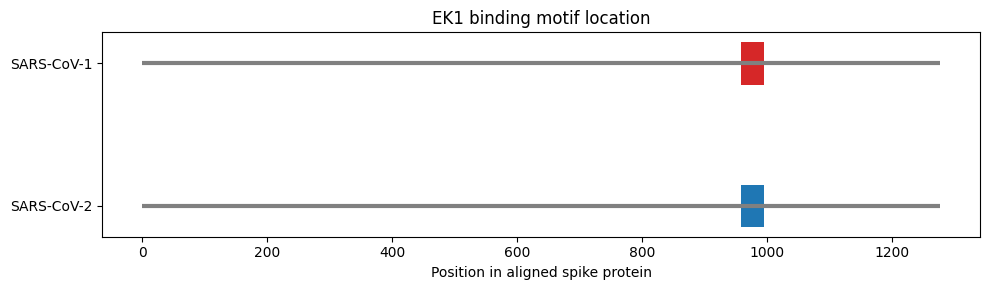

In [24]:
import matplotlib.pyplot as plt

# SARS-CoV-2 aligned, SARS-CoV-1 aligned
aln_sars2, aln_sars1 = alignments["Human-SARS"]

# For each residue number record which alignment column it sits in 
sars1_columns = []
for col in range(len(aln_sars1)):
    if aln_sars1[col] != "-":
        sars1_columns.append(col)

sars2_columns = []
for col in range(len(aln_sars2)):
    if aln_sars2[col] != "-":
        sars2_columns.append(col)

# Motif start and end on the shared axis
s1_plot_start = sars1_columns[s1_start]
s1_plot_end = sars1_columns[s1_start + len(s1_aligned_spike) - 1]
s2_plot_start = sars2_columns[s2_start]
s2_plot_end = sars2_columns[s2_start + len(s2_aligned_spike) - 1]

fig, ax = plt.subplots(figsize=(10, 3))

# Whole spike protein
ax.hlines(1, 0, len(aln_sars1), color="grey", linewidth=3)
ax.hlines(0, 0, len(aln_sars2), color="grey", linewidth=3)

# EK1 motif location
ax.barh(1, s1_plot_end - s1_plot_start, left=s1_plot_start, height=0.3, color="tab:red")
ax.barh(0, s2_plot_end - s2_plot_start, left=s2_plot_start, height=0.3, color="tab:blue")

ax.set_yticks([0, 1])
ax.set_yticklabels(["SARS-CoV-2", "SARS-CoV-1"])
ax.set_xlabel("Position in aligned spike protein")
ax.set_title("EK1 binding motif location")
plt.tight_layout()
plt.savefig("problem-bonus.png", dpi=150)
plt.show()

In [25]:
binding_motif_present = """
Does the SARS-CoV-2 spike protein contain the EK1 binding motif?

Yes! The best local alignment of the EK1 motif against the SARS-CoV-2 spike gives a score of 47
with a coverage of 37/42 motif positions with no gaps at position 956-992. This is identical to the 
best hit in SARS-CoV-1, which also scored 47 with 37 positions covered and no gaps, at residues 938-974.
Since SARS-CoV-1 must contain a valid binding site, using it to calibrate the scoring function means 
SARS-CoV-2 contains the same one. However, it is important to note that the hit was partial with 37/42 positions and 
thus is not a perfect match.
"""

In [ ]:
binding_motif_similarity = """
Are SARS-CoV-1 and SARS-CoV-2 motifs comparable? What percentage of the aminoacids match between the motifs?

Yes they are comparable! The two motif regions are 37 amino acids long and all 37 are identical with a 100% match rate. 
As evident in the plot, they also sit in the same place on the aligned spike proteins. Their start positions differ 
(937 in SARS-CoV-1, 955 in SARS-CoV-2) only because the SARS-CoV-2 spike has extra residues earlier in the sequence.
"""

In [ ]:
EK1_drug_efficacy = """
Does the treatment work on COVID-19 patients? Search through literature and provide at least two references.
"""